# This file plots the normalized hysteresis area for H+ concentrations

author: Eike E. Köhn ......
date: July 29, 2025 ......
instructions: can be run with environment "conda env:pangeo-meso-2024.01.22" on spirit1

## Import packages

In [1]:
print('Loading packages...')
import sys
sys.path.append('../00_modules/.')
from import_packages import PackageGetter
globals().update(PackageGetter.import_standard_packages_for_analysis_and_plotting())
globals().update(PackageGetter.import_custom_packages())

Loading packages...


## Decide if figures are to be saved (and if so the directory)

In [2]:
savefigs = False
plot_dir = Plotter._get_plot_dir('standard')

## Set the parameters for the analysis of the 1pctCO2-cdr run

In [3]:
print('Setting parameters...')
run_params = Params.standard_set_1pctCO2cdr() #Params.test_set_1pctCO2cdr()  #

Setting parameters...


## Choose the variable that is to be analyzed - and its temporal resolution

In [4]:
print('Choosing variable and temporal resolution....')
variable_to_analyze = 'hplus'
depth_to_analyze = 'surface'
temporal_resolution = 'annual_means'

Choosing variable and temporal resolution....


## Get the model data for the variable of choice

In [5]:
print("Opening the variable's model dataset...")
run_paths = ModelDataGetter._identify_path_strings(run_params,variable_to_analyze,depth_to_analyze)
ds_data   = ModelDataGetter._open_datasets(run_paths)

Opening the variable's model dataset...


## Since the loaded data is pH and not H+, i need to convert here. In the same process i convert the H+ data already to nmol kg-1. Attention to not use run_paths afterwards anymore since this is still pointing to pH data.

In [6]:
ds_data = ModelDataGetter._convert_ph_to_hplus(ds_data,convert_to_nmol_per_kg=True)
del run_paths # deleting here run_paths for safety reasons

## Get the additional ocean mask, area weights, atmospheric CO2, and ocean regions

In [7]:
print('Getting miscellaneous data...')
da_omask  = MiscDataGetter._get_ocean_mask()
da_area   = MiscDataGetter._get_grid_cell_areas()
ds_atmCO2 = MiscDataGetter._get_atmospheric_CO2(run_params)
ds_oregs, reg_lookup_dict  = MiscDataGetter._get_ocean_regions()

Getting miscellaneous data...
james' way to define atm. xco2, but taking into account that MIROC-ES2L and CanESM5 models branched at 139 and 141 years respectively (instead of 140).
james' way to define atm. xco2, but taking into account that MIROC-ES2L and CanESM5 models branched at 139 and 141 years respectively (instead of 140).
james' way to define atm. xco2, but taking into account that MIROC-ES2L and CanESM5 models branched at 139 and 141 years respectively (instead of 140).
james' way to define atm. xco2, but taking into account that MIROC-ES2L and CanESM5 models branched at 139 and 141 years respectively (instead of 140).
james' way to define atm. xco2, but taking into account that MIROC-ES2L and CanESM5 models branched at 139 and 141 years respectively (instead of 140).
james' way to define atm. xco2, but taking into account that MIROC-ES2L and CanESM5 models branched at 139 and 141 years respectively (instead of 140).
james' way to define atm. xco2, but taking into account th

# Perform the Taylor decomposition

In [8]:
print('Do the freshwater Taylor decomposition......')
contribution_terms = TaylorFuncs._perform_taylor_decomposition(run_params,variable_to_analyze,depth_to_analyze,temporal_resolution)


Do the freshwater Taylor decomposition......


Exception ignored in: <bound method IPythonKernel._clean_thread_parent_frames of <ipykernel.ipkernel.IPythonKernel object at 0x5555771909e0>>
Traceback (most recent call last):
  File "/net/nfs/tools/u20/Python/miniconda3_py311_23.11.0-2/envs/pangeo-meso-2024.01.22/lib/python3.11/site-packages/ipykernel/ipkernel.py", line 770, in _clean_thread_parent_frames
    def _clean_thread_parent_frames(

KeyboardInterrupt: 
Exception ignored in: <bound method IPythonKernel._clean_thread_parent_frames of <ipykernel.ipkernel.IPythonKernel object at 0x5555771909e0>>
Traceback (most recent call last):
  File "/net/nfs/tools/u20/Python/miniconda3_py311_23.11.0-2/envs/pangeo-meso-2024.01.22/lib/python3.11/site-packages/ipykernel/ipkernel.py", line 770, in _clean_thread_parent_frames
KeyboardInterrupt: 

KeyboardInterrupt



## Pick example locations and regions for local analysis

In [ ]:
print('Get time series....')
set_of_loc_reg = MiscDataGetter._standard_set_of_regions_locations()
print('Chosen locations: ', set_of_loc_reg)


## Compute the regional mean time series of the contributions

In [ ]:
print('Computing the regional mean time series of the individual contributions.....')
contribution_regional_time_series = dict()
for contribution_term_name in contribution_terms.keys():
    print(f'Computing the regional mean time series for: {contribution_term_name}')
    contribution_regional_time_series[contribution_term_name] = MMFuncs._calc_regional_means(run_params,set_of_loc_reg,contribution_terms[contribution_term_name],temporal_resolution)


## Convert results to nmol per kg

In [ ]:
for key in contribution_regional_time_series.keys():
    for loc_reg in set_of_loc_reg:
        if isinstance(loc_reg,list):
            loc_reg = f'point_{loc_reg[0]}_{loc_reg[1]}'
        contribution_regional_time_series[key][loc_reg] *= Converter._Converter__conversion_factors('from_1_to_nano')

Plot the regional mean time series for a sample region, such as the central Arctic (make sure it is in set_of_loc_reg) ......


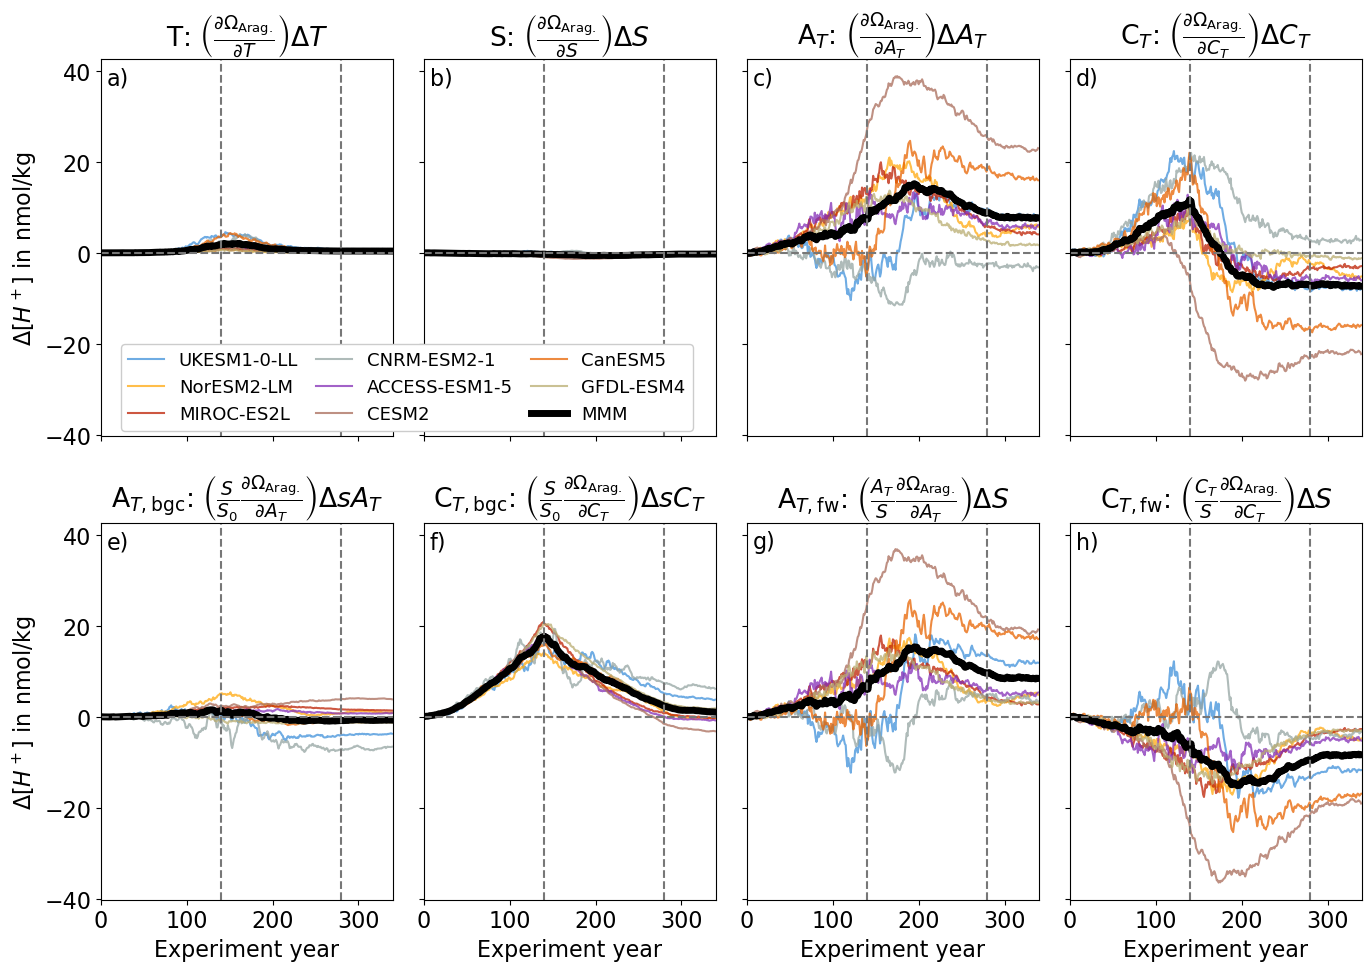

In [12]:
print('Plot the regional mean time series for a sample region, such as the central Arctic (make sure it is in set_of_loc_reg) ......')
fig, ax = TaylorFuncs._plot_regional_timeseries_for_all_contributions(run_params, contribution_regional_time_series,'central Arctic',variable_to_analyze)


## Compute the regional mean time series for the variable to analyze

In [13]:
print('Get time series....')
variable_regional_time_series = MMFuncs._calc_regional_means(run_params,set_of_loc_reg,ds_data,temporal_resolution)

Get time series....


## Make a plot comparing the sum of the Taylor expansion terms with the full model output in a particular region (multimodel mean)

Make the sanity check plot....


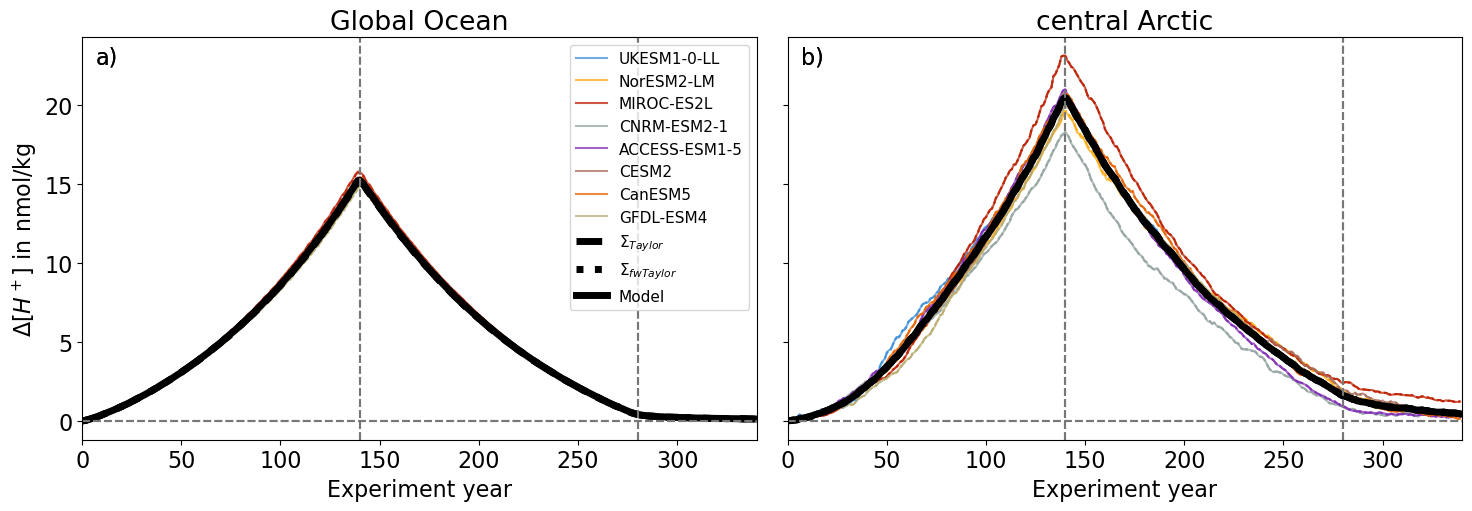

In [14]:
print('Make the sanity check plot....')
fig, ax = TaylorFuncs._plot_comparison_taylor_sum_vs_model_output(run_params,'central Arctic',variable_regional_time_series,contribution_regional_time_series,variable_to_analyze)


## Now plot the multimodel mean error of the decomposition as a function of time

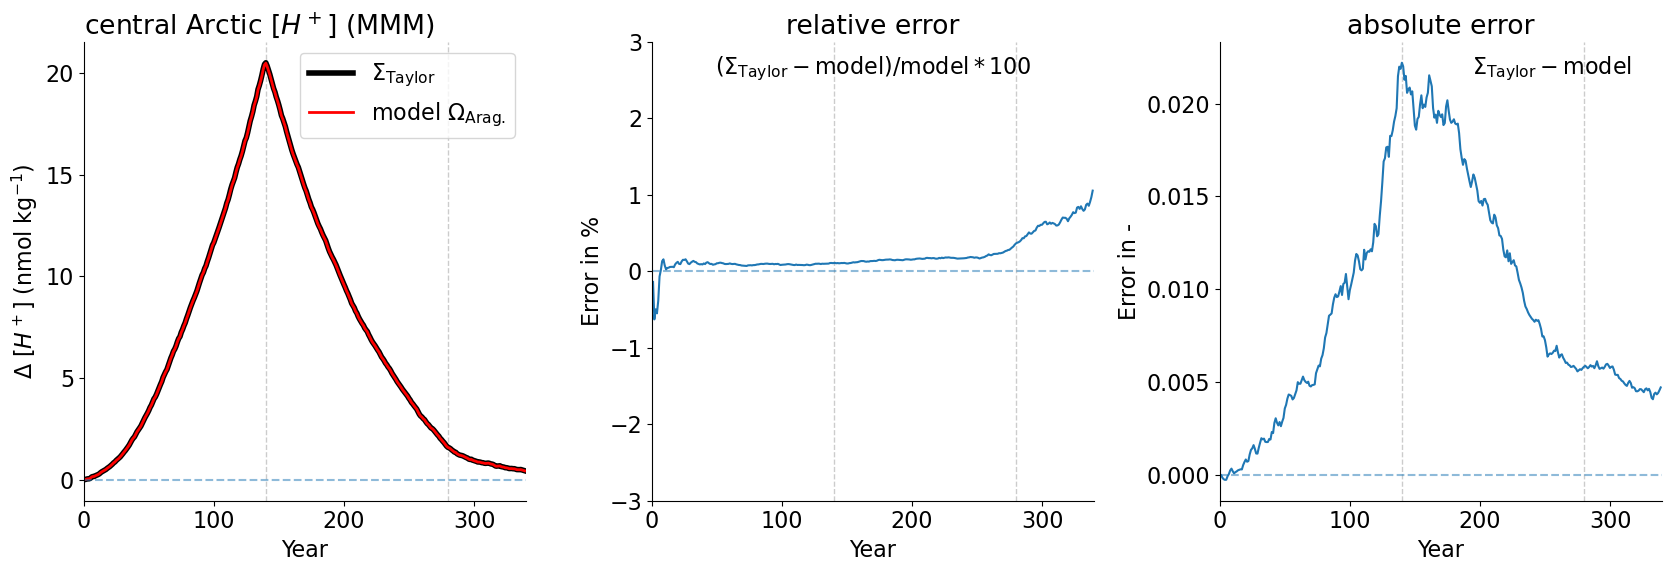

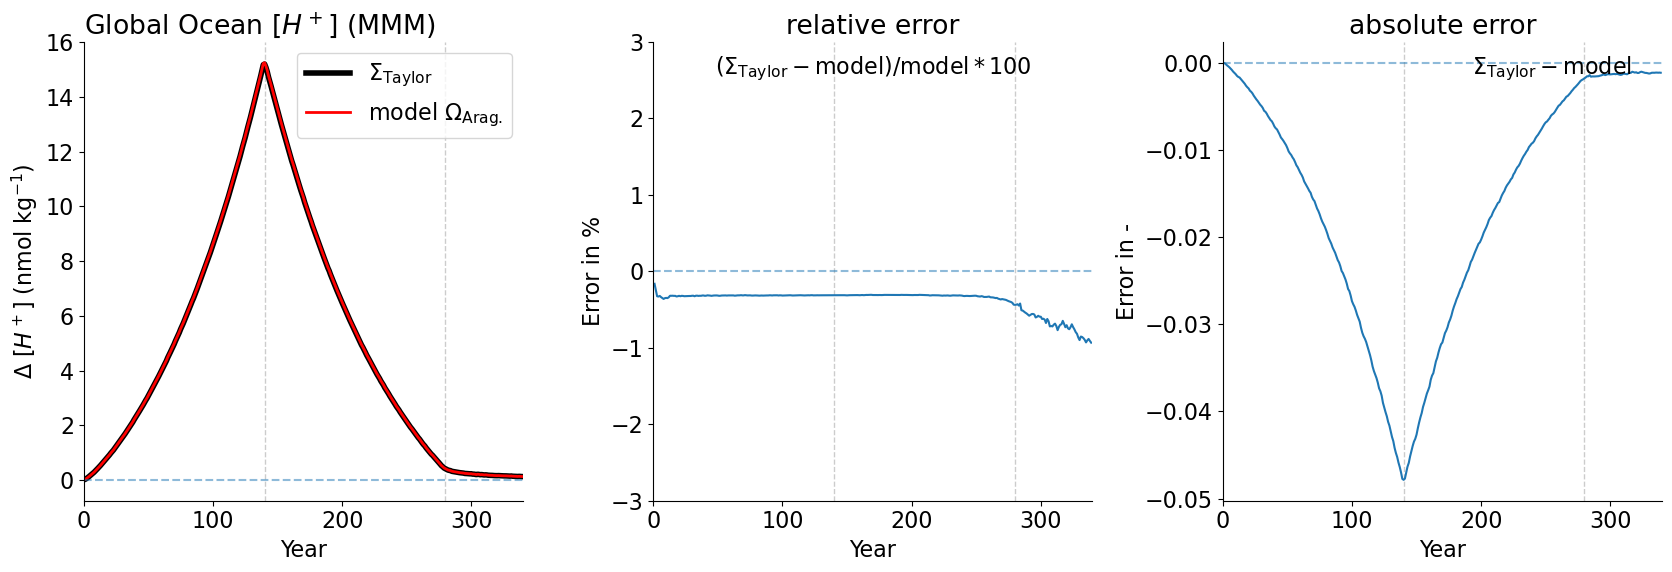

In [15]:
fig, ax = TaylorFuncs._plot_decomposition_error_time_series(run_params,
                                                         contribution_regional_time_series,
                                                         variable_regional_time_series,
                                                         'central Arctic',
                                                         variable_to_analyze)

fig, ax = TaylorFuncs._plot_decomposition_error_time_series(run_params,
                                                         contribution_regional_time_series,
                                                         variable_regional_time_series,
                                                         'Global Ocean',
                                                         variable_to_analyze)



## Now compute the hysteresis areas for the direct model output

In [16]:
print('Compute the hysteresis areas for the model output.....')
hyst_dict_model = HystFuncs._calc_hysteresis_areas_3D_multimodel(run_params,ds_data,temporal_resolution,ds_atmCO2)
reorganized_hyst_dict_model = HystFuncs._reorganize_hysteresis_dict_model_direct(run_params, hyst_dict_model)

Compute the hysteresis areas for the model output.....
Calculating hysteresis area for model UKESM1-0-LL (key 2)...
Calculating hysteresis area for model NorESM2-LM (key 3)...
Calculating hysteresis area for model MIROC-ES2L (key 4)...
Calculating hysteresis area for model CNRM-ESM2-1 (key 5)...
Calculating hysteresis area for model ACCESS-ESM1-5 (key 6)...
Calculating hysteresis area for model CESM2 (key 7)...
Calculating hysteresis area for model CanESM5 (key 8)...
Calculating hysteresis area for model GFDL-ESM4 (key 9)...


## Now compute the hysteresis areas for the taylor terms (this takes a long time)......

In [ ]:
print('Compute the hysteresis areas for the individual contribution terms..Or load precomputed ones (since it takes a long time).....')
load_precomputed_hysteresis_areas = False
save_computed_hysteresis_areas = True

# Compute the hysteresis dict
if load_precomputed_hysteresis_areas == True:
    print('loading the calculated hysteresis dict for the indicidual contributions....')
    indir = '/data/ekoehn/projects/arctic_acidification_reversibility/data/hysteresis_for_1pctCO2-cdr/'
    reorganized_hyst_dict_taylor = xr.open_dataset(f'{indir}hyst_areas_for_contributions_{variable_to_analyze}.nc')
else:
    hyst_dict_taylor = dict()
    for contributor in contribution_terms.keys():
        print(contributor)
        contributor_ds = contribution_terms[contributor]      
        hyst_dict_taylor[contributor] = HystFuncs._calc_hysteresis_areas_3D_multimodel(run_params,contributor_ds,temporal_resolution,ds_atmCO2)
    reorganized_hyst_dict_taylor = HystFuncs._reorganize_hysteresis_dict(run_params,hyst_dict_taylor) 
    # Save the hysteresis dict
    if save_computed_hysteresis_areas == True:
        print('saving the calculated hysteresis dict for the indicidual contributions....')
        outdir = '/data/ekoehn/projects/arctic_acidification_reversibility/data/hysteresis_for_1pctCO2-cdr/'
        reorganized_hyst_dict_taylor.to_netcdf(f'{outdir}hyst_areas_for_contributions_{variable_to_analyze}.nc')


Compute the hysteresis areas for the individual contribution terms..Or load precomputed ones (since it takes a long time).....
t
Calculating hysteresis area for model UKESM1-0-LL (key 2)...
Calculating hysteresis area for model NorESM2-LM (key 3)...


## Compute regional averages of the hysteresis areas

In [17]:
print('Compute the regional mean hysteresis metrics for the direct model output......')
da = reorganized_hyst_dict_model.model
regional_hysteresis_model =  MMFuncs._calc_regional_means(run_params,set_of_loc_reg,da,temporal_resolution)

Compute the regional mean hysteresis metrics for the direct model output......


In [18]:
print('Computing the regional mean hysteresis metrics of the individual contributions.....')
regional_hysteresis_taylor_contributions = dict()
for contributor in reorganized_hyst_dict_taylor.keys():
    print(f'Computing the regional mean hysteresis metric: {contributor}')
    da = reorganized_hyst_dict_taylor[contributor]
    regional_hysteresis_taylor_contributions[contributor] = MMFuncs._calc_regional_means(run_params,set_of_loc_reg,da,temporal_resolution)

Computing the regional mean hysteresis metrics of the individual contributions.....
Computing the regional mean hysteresis metric: t
Computing the regional mean hysteresis metric: s
Computing the regional mean hysteresis metric: alk
Computing the regional mean hysteresis metric: dic
Computing the regional mean hysteresis metric: alk_bgc
Computing the regional mean hysteresis metric: dic_bgc
Computing the regional mean hysteresis metric: alk_dilution
Computing the regional mean hysteresis metric: dic_dilution
Computing the regional mean hysteresis metric: dilution_terms
Computing the regional mean hysteresis metric: bgc_terms
Computing the regional mean hysteresis metric: alk_dic
Computing the regional mean hysteresis metric: taylor_sum
Computing the regional mean hysteresis metric: fwtaylor_sum


## Now make the time series and bar plot for the regional hysteresis area decomposition ....

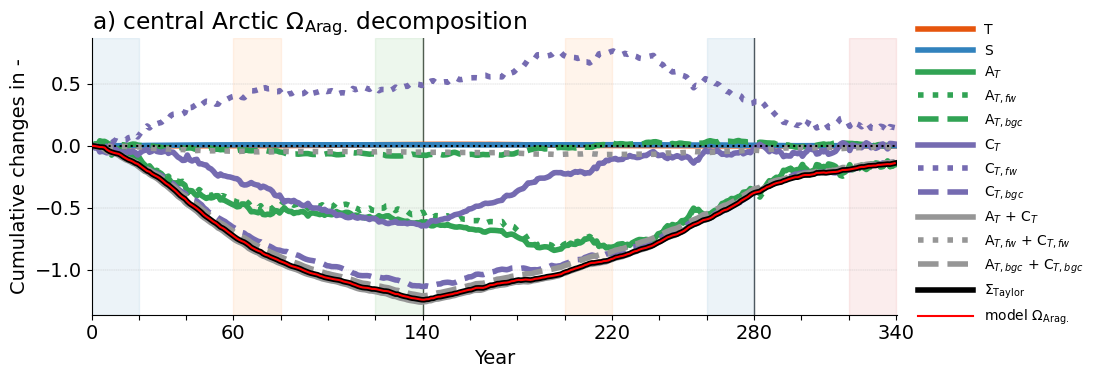

In [19]:
fig, ax = Plotter._plot_time_series_of_regional_hysteresis_decomposition(run_params, 
                                                                         variable_to_analyze, 
                                                                         'central Arctic', #'Global Ocean', #
                                                                         variable_regional_time_series, 
                                                                         contribution_regional_time_series)


/home/ekoehn/jobs/jupyter/arctic_acidification_reversibility/03_analysis_and_plotting/../00_modules/./funcs_for_plotting.py:544: UserWarning: Tight layout not applied. tight_layout cannot make axes width small enough to accommodate all axes decorations
  legend_ncols = 1 if variable_to_analyze == 'omegaa' else 2


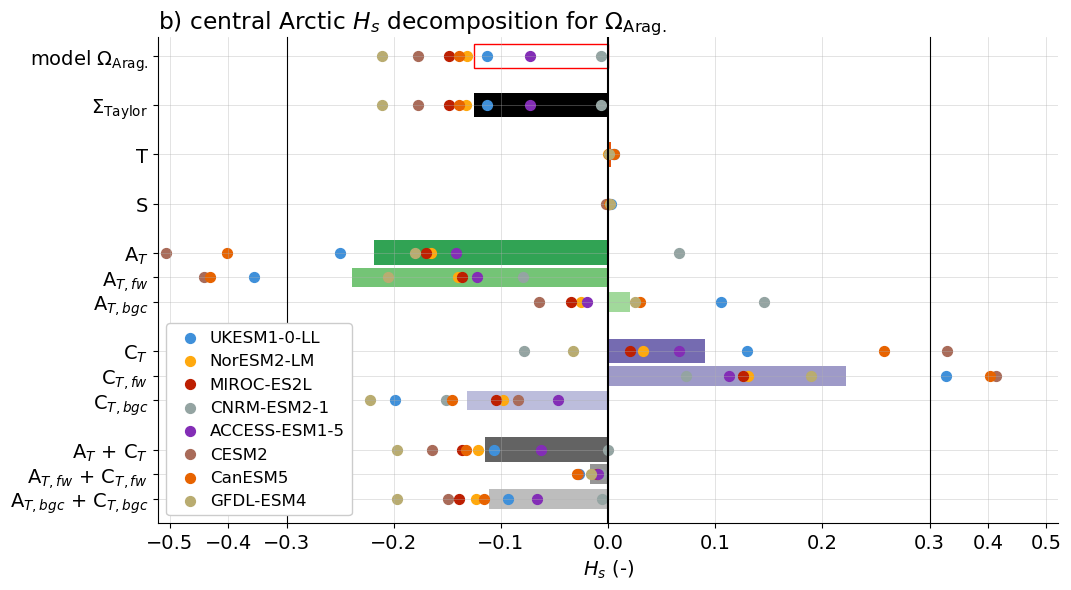

In [20]:
fig, ax = Plotter._plot_bars_of_regional_hysteresis_decomposition(run_params, 
                                                          variable_to_analyze, 
                                                          'central Arctic', 
                                                          #'central Arctic', 
                                                          regional_hysteresis_model, 
                                                          regional_hysteresis_taylor_contributions)


## Plot time slice averages, combining the signed hysteresis area and the evolution of the individual terms

Compute time slice averages.....
Make the plot for contribution t....


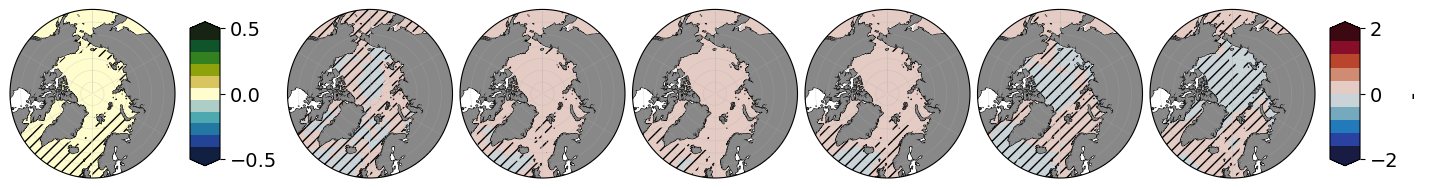

Make the plot for contribution s....


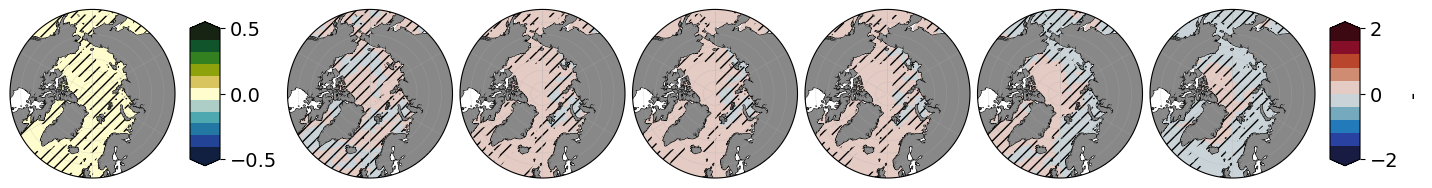

Make the plot for contribution dic....


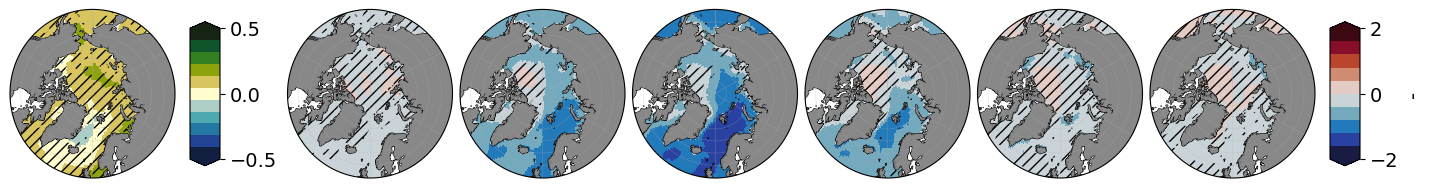

Make the plot for contribution alk....


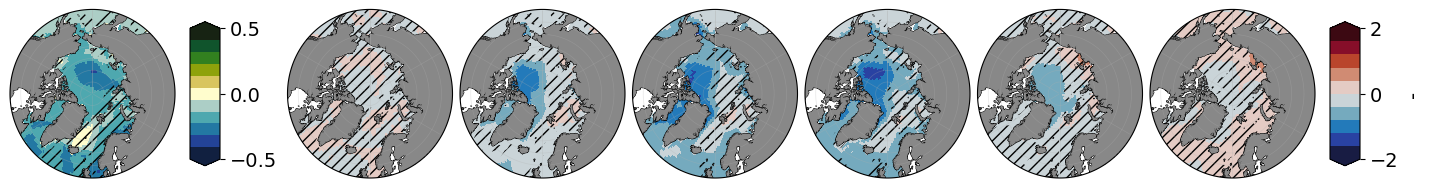

Make the plot for contribution alk_bgc....


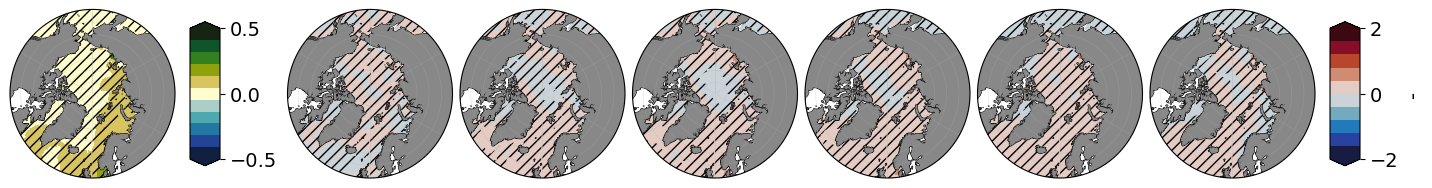

Make the plot for contribution dic_bgc....


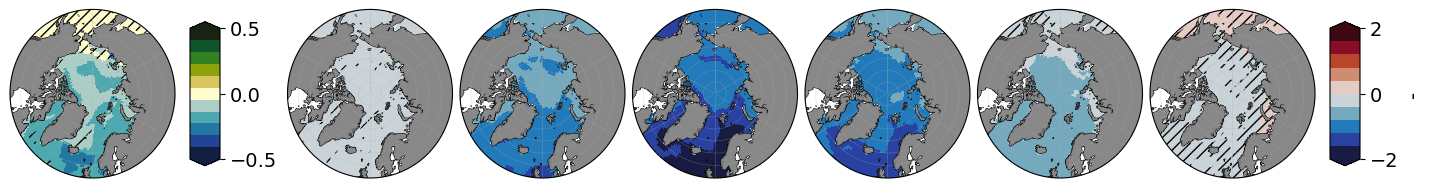

Make the plot for contribution alk_dilution....


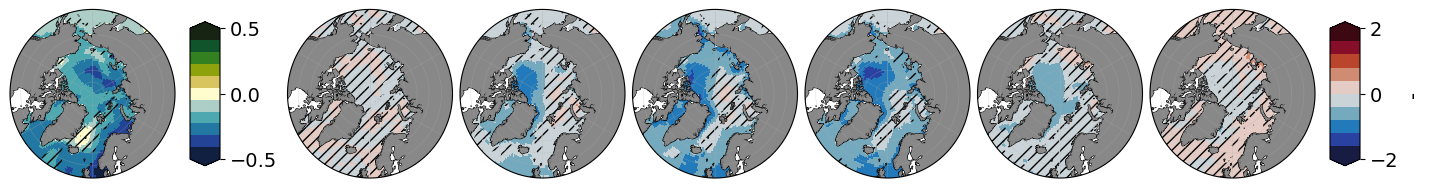

Make the plot for contribution dic_dilution....


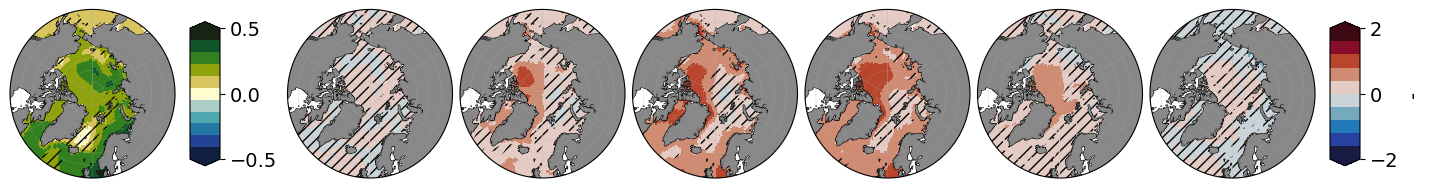

Make the plot for contribution bgc_terms....


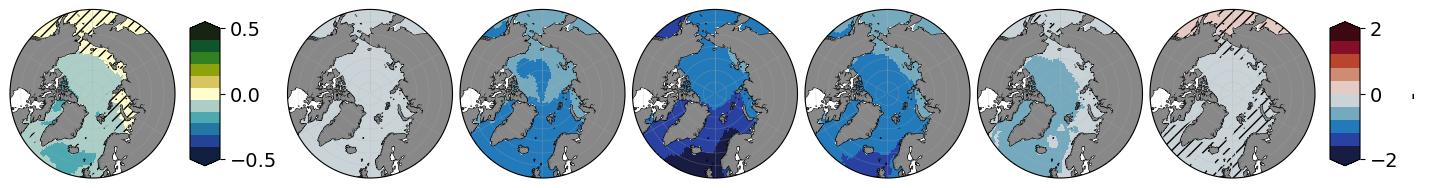

Make the plot for contribution dilution_terms....


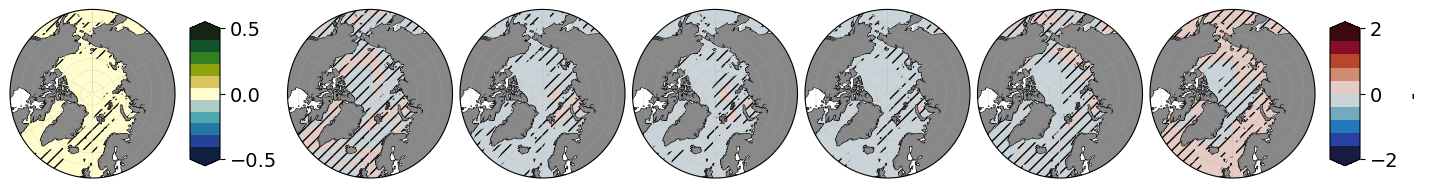

Make the plot for contribution taylor_sum....


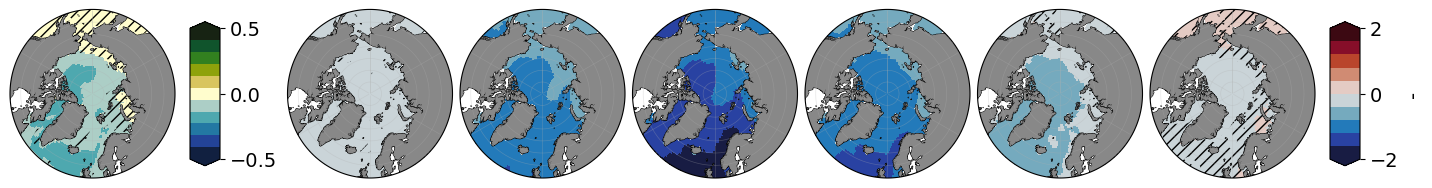

Make the plot for contribution fwtaylor_sum....


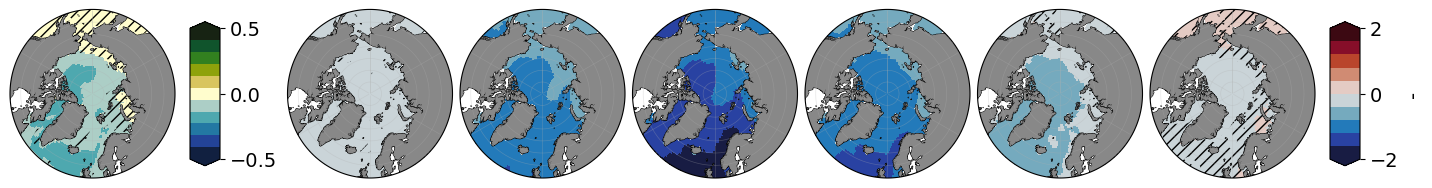

In [21]:
print('Compute time slice averages.....')
contributors = ['t','s','dic','alk','alk_bgc','dic_bgc','alk_dilution','dic_dilution','bgc_terms','dilution_terms','taylor_sum','fwtaylor_sum']
# loop over the taylor contributions, calc the time slice averages, get the multimodel mean signed hysteresis area, and make the plot
for contributor in contributors:
    print(f'Make the plot for contribution {contributor}....')

    # get the hysteresis area (mmm and agreement)
    signed_hyst_areas = reorganized_hyst_dict_taylor[contributor].sel(h_definition='signed_hysteresis_area')

    # compute the time slice averages 
    time_slice_averages_mmm, time_slice_averages_agreement = MMFuncs._calc_time_slice_averages(contribution_terms[contributor],
                                                                                               signed_hyst_areas,
                                                                                               None,
                                                                                               time_slices='hysteresis_areas',
                                                                                               time_slice_type='absolute_value')
    
    Plotter._plot_time_slice_averages(time_slice_averages_mmm,
                                      time_slice_averages_agreement,
                                      time_slice_type='anom_to_preindustrial_initial',
                                      vmin=-5,vmax=-5,cmap=plt.get_cmap('cmo.delta',11),
                                      amin=0,amax=20,amap=plt.get_cmap('cmo.amp',10),
                                      unit=r'nmol kg$^{-1}$',include_region_mask=False)


## Make global and arctic plots for the signed hysteresis areas of the model data

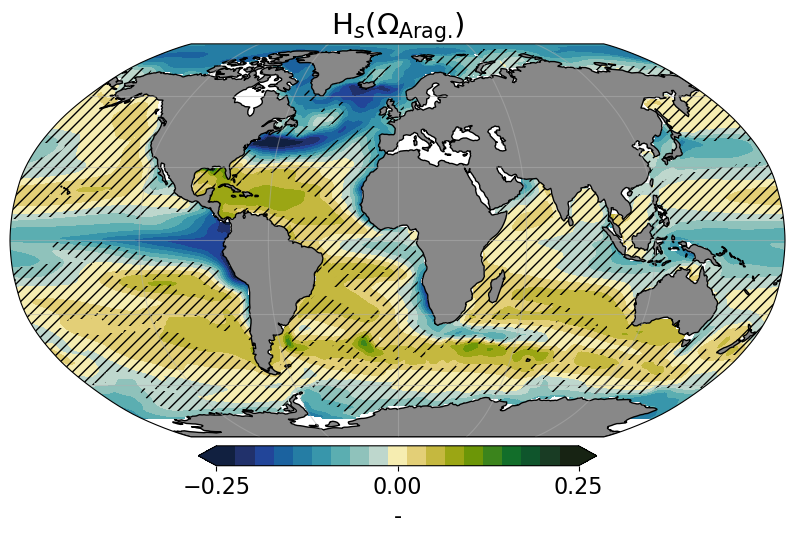

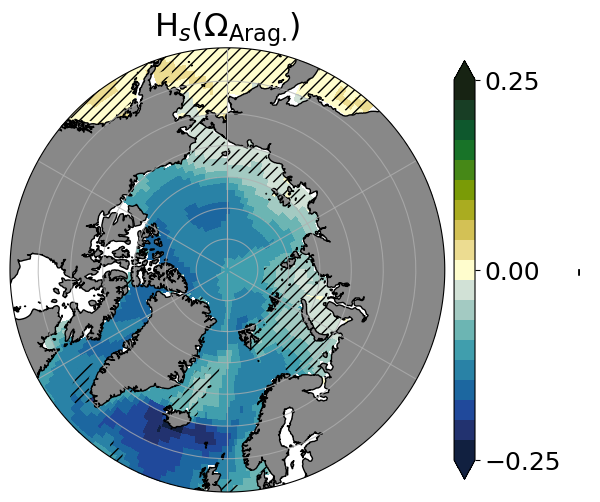

In [22]:
# get the hysteresis area (mmm and agreement)
signed_hyst_areas = reorganized_hyst_dict_model.model.sel(h_definition='signed_hysteresis_area')
signed_hyst_areas_mmm = signed_hyst_areas.mean(dim='run_keys')
signed_hyst_areas_agreement = MMFuncs._calc_model_agreement(signed_hyst_areas,agreement_type='sign',agreement_thresh='at_least_80percent_agree')

fig,ax = Plotter.plot_global_map(signed_hyst_areas_mmm,
                                 [],
                                 -5,
                                 5,
                                 20,
                                 plt.get_cmap('cmo.delta',20),
                                 [-5,-2.5,0,2.5,5],
                                 'both',
                                 r'nmol kg$^{-1}$',
                                 r'H$_s$($[H^+]$)',
                                 agreement=signed_hyst_areas_agreement)

fig,ax = Plotter.plot_arctic_map(signed_hyst_areas_mmm,
                                 [],
                                 -5,
                                 5,
                                 20,
                                 plt.get_cmap('cmo.delta',20),
                                 [-5,-2.5,0,2.5,5],
                                 'both',
                                 r'nmol kg$^{-1}$',
                                 r'H$_s$($[H^+]$)',
                                 agreement=signed_hyst_areas_agreement)

## Make global and arctic plots for the signed hysteresis areas of the individual contributors

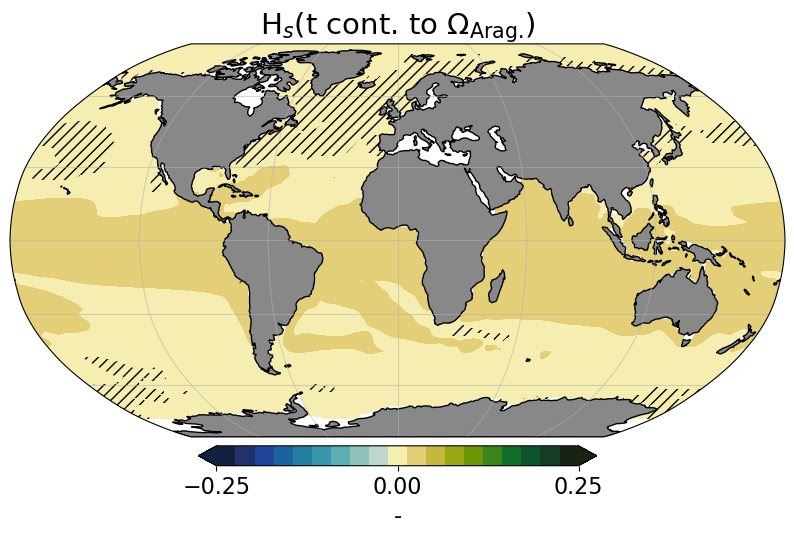

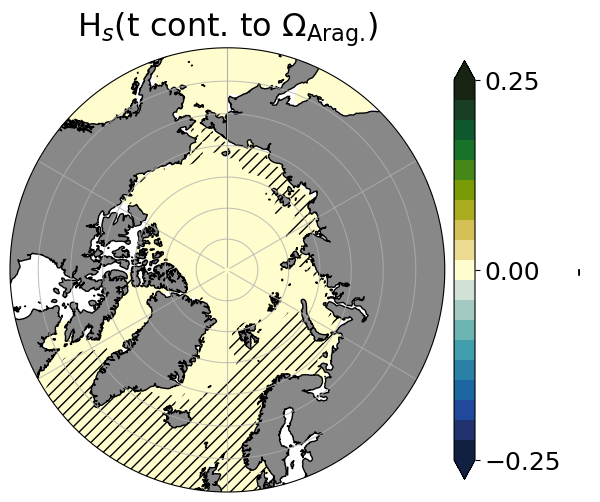

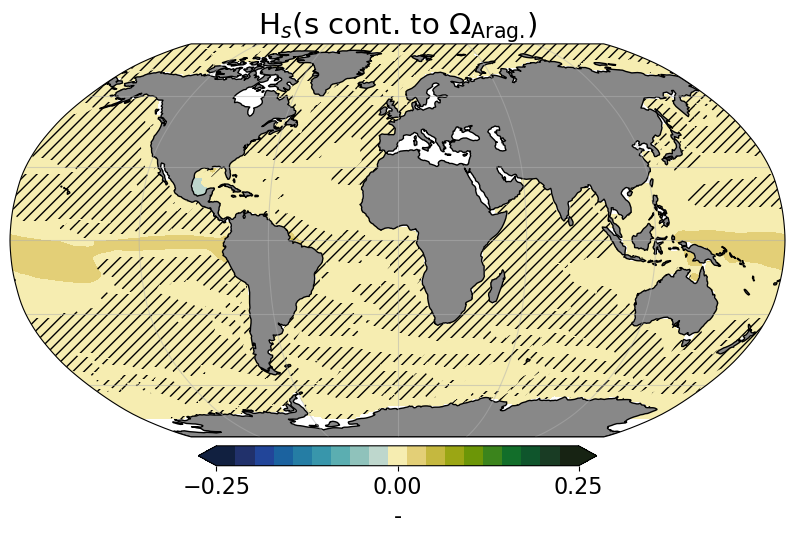

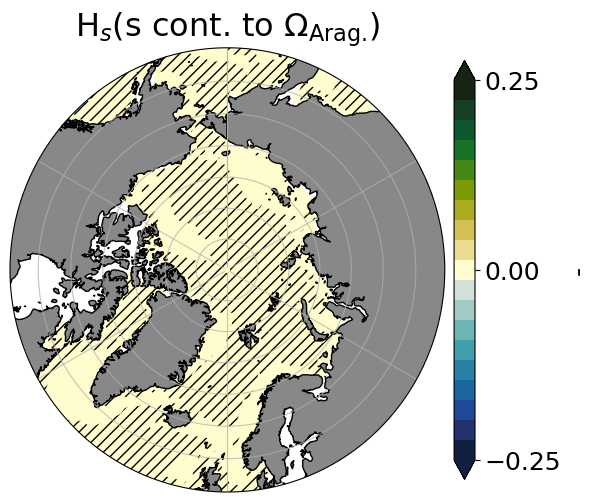

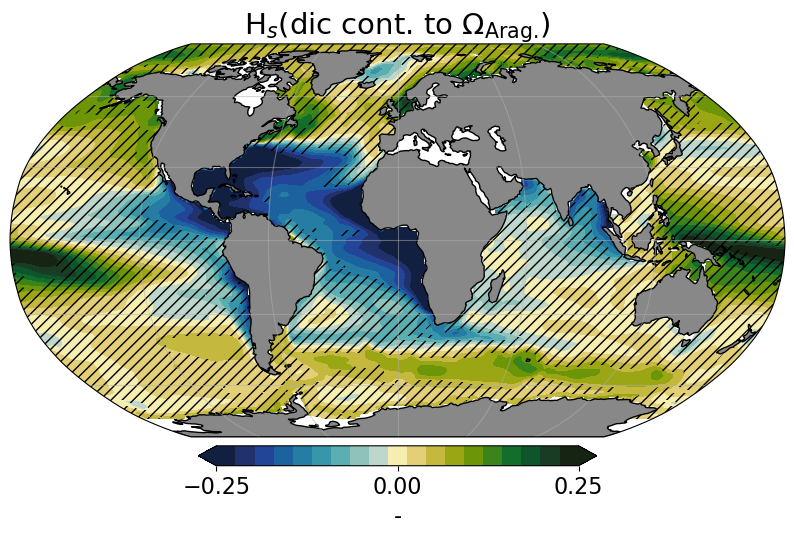

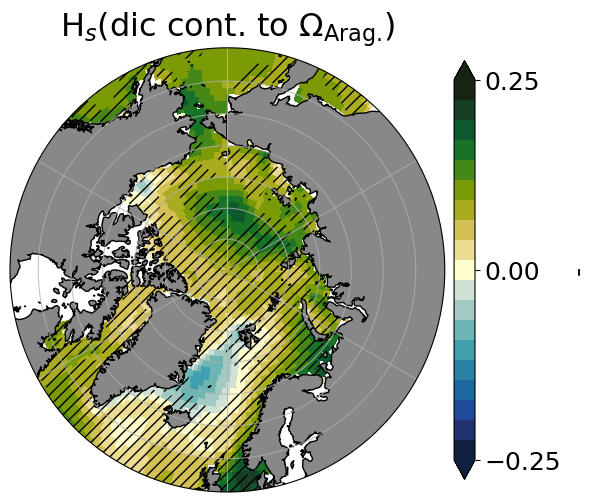

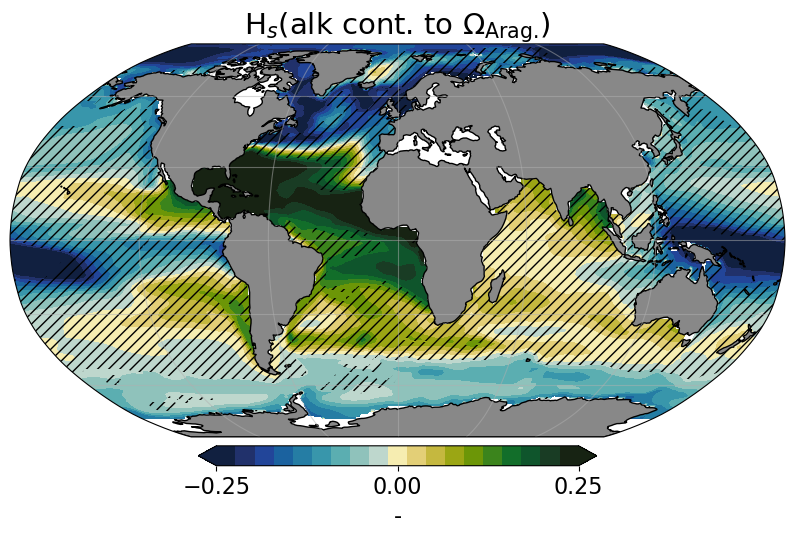

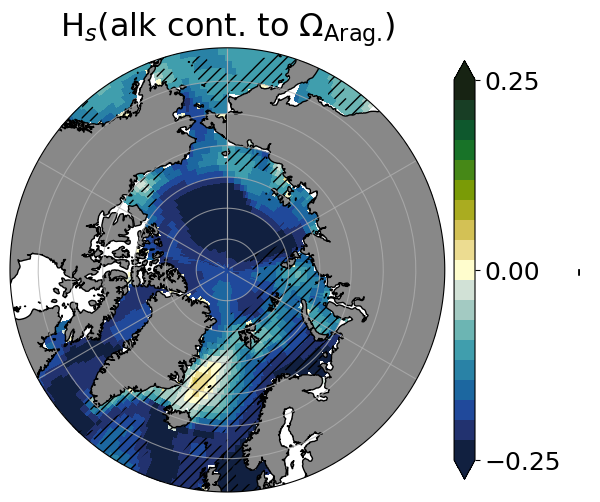

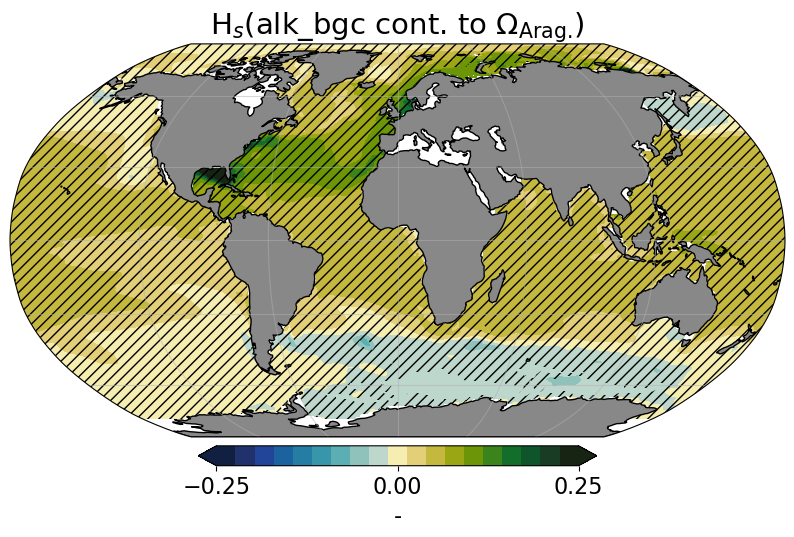

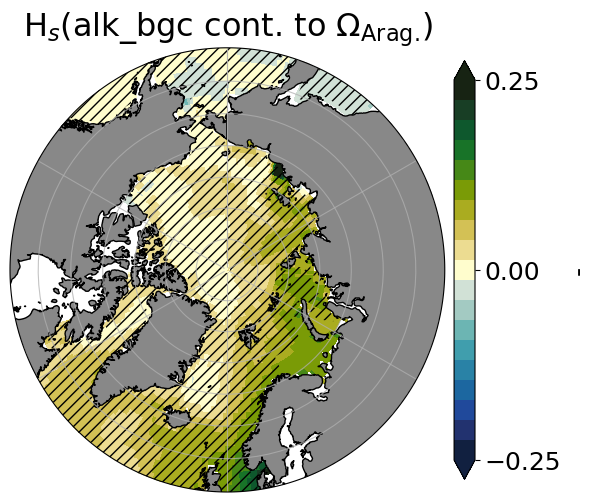

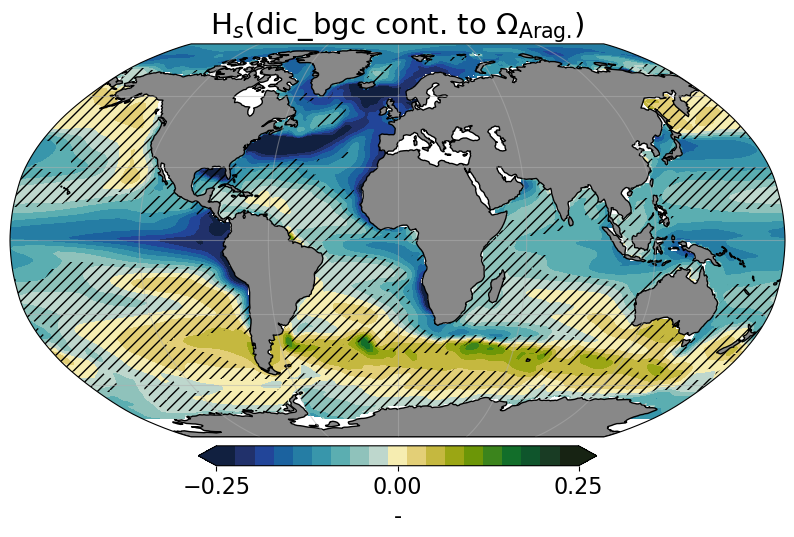

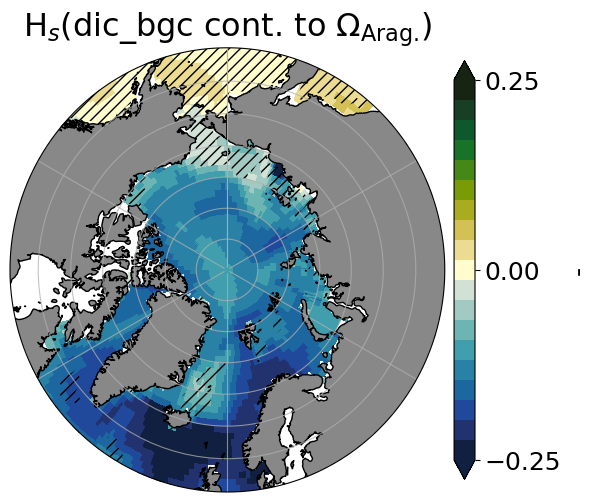

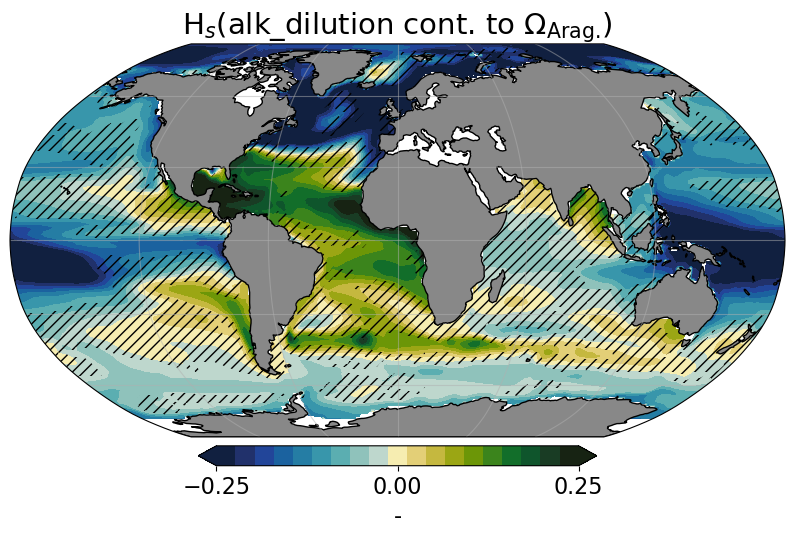

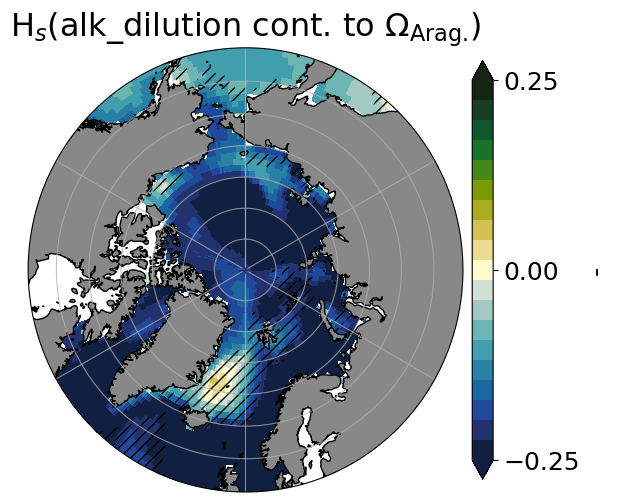

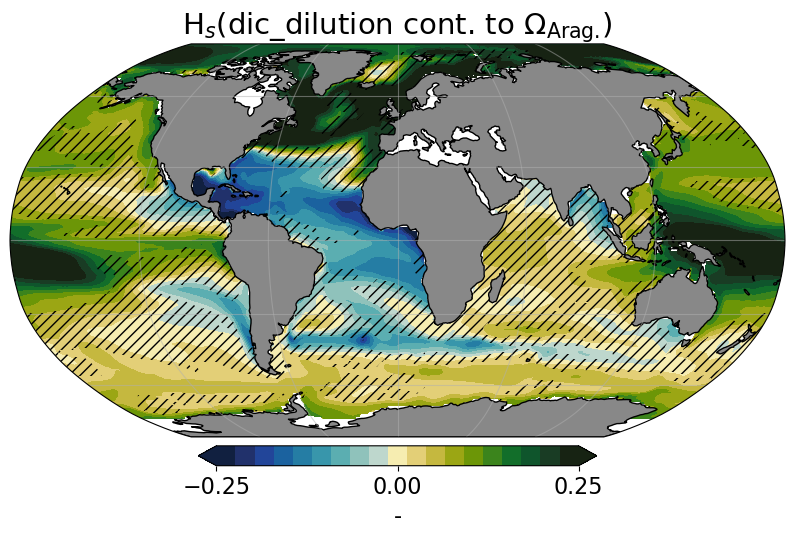

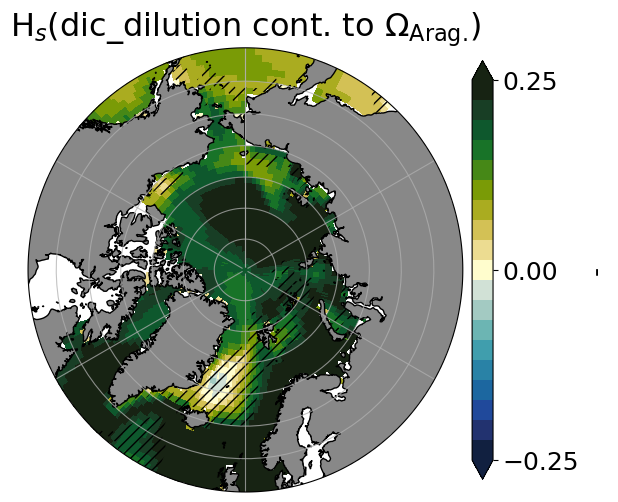

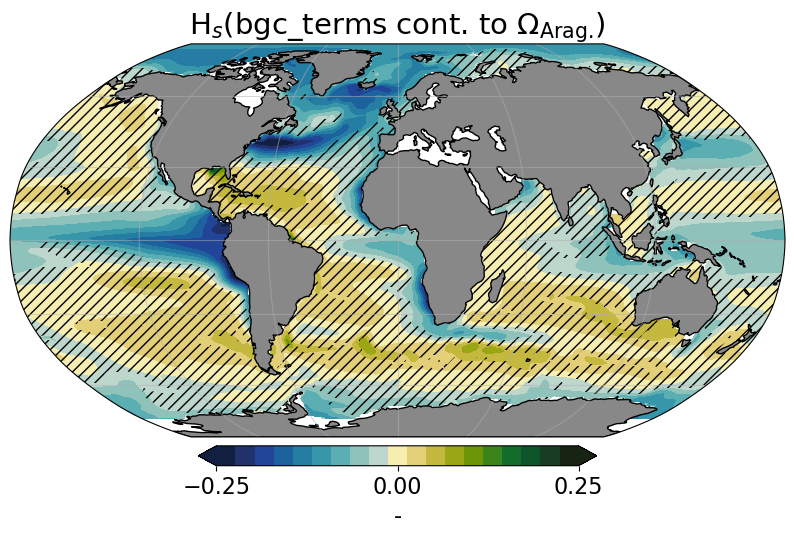

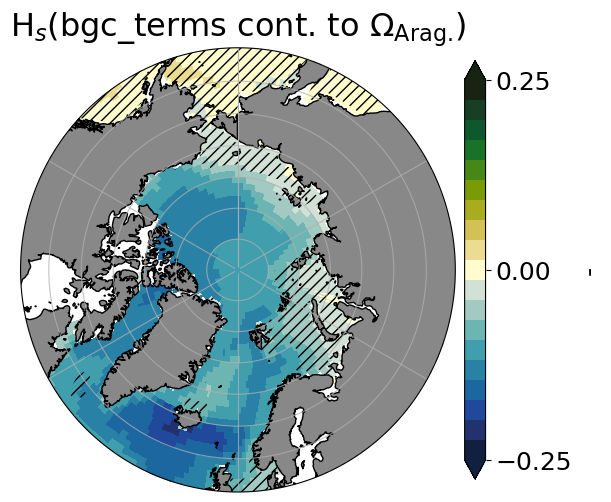

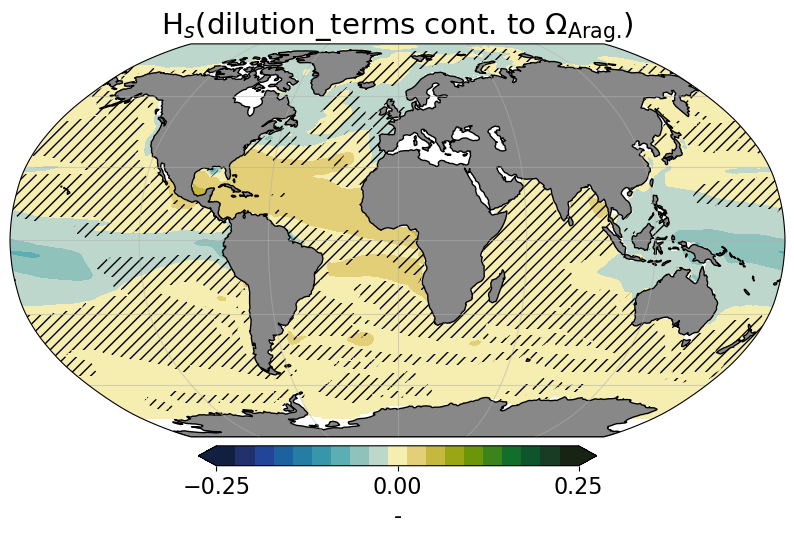

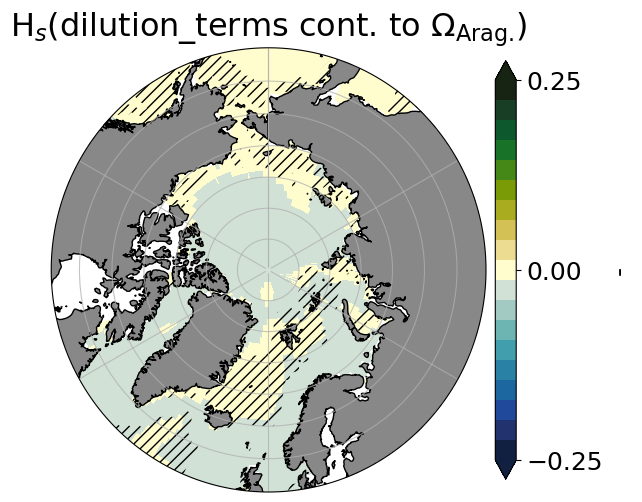

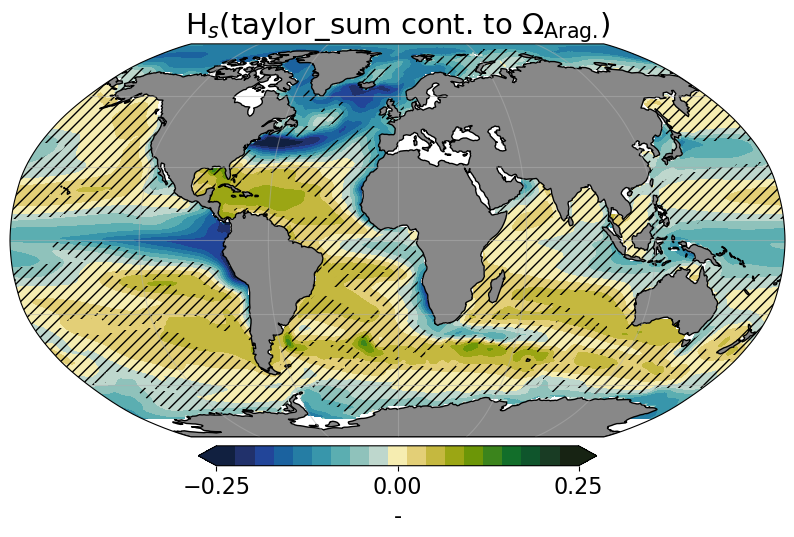

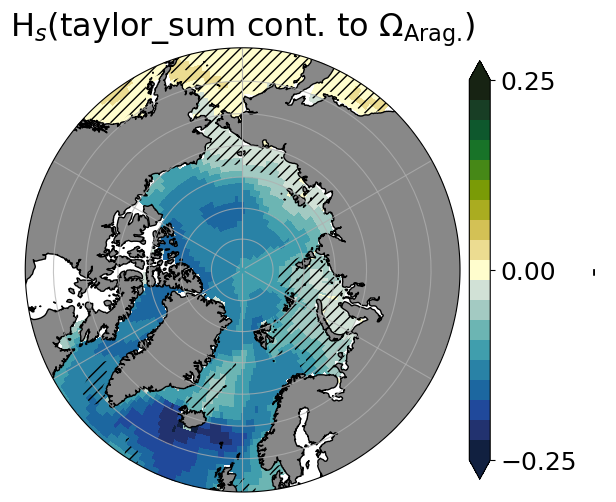

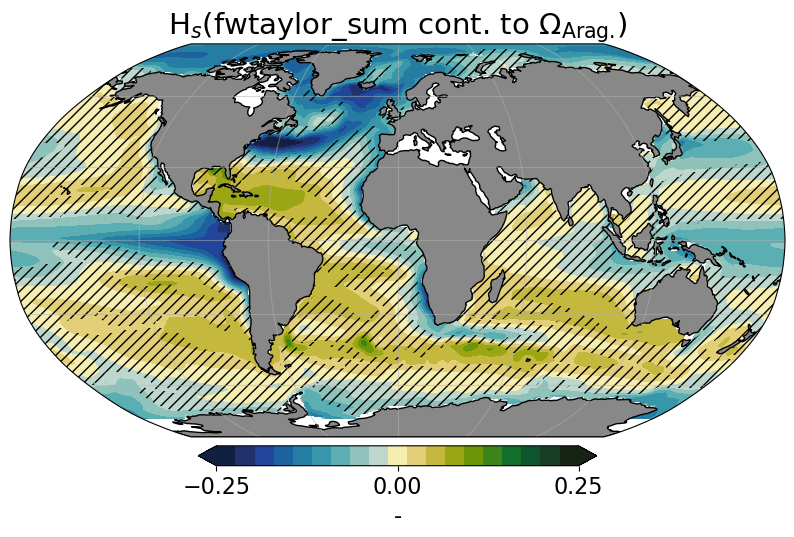

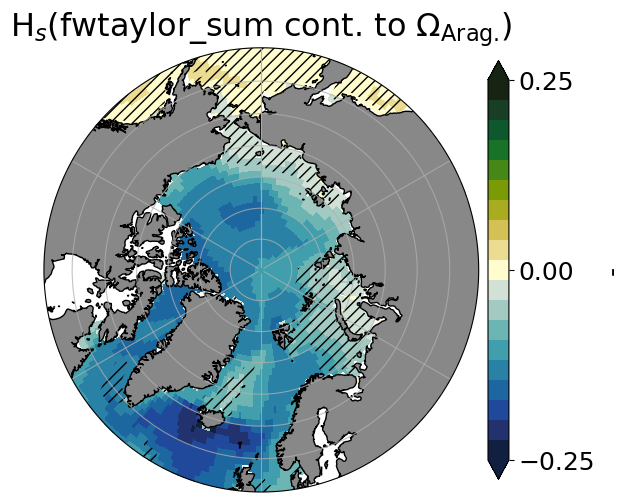

In [23]:
# get the hysteresis area (mmm and agreement)
for contributor in contributors:

    #
    signed_hyst_areas = reorganized_hyst_dict_taylor[contributor].sel(h_definition='signed_hysteresis_area')
    signed_hyst_areas_mmm = signed_hyst_areas.mean(dim='run_keys')
    signed_hyst_areas_agreement = MMFuncs._calc_model_agreement(signed_hyst_areas,agreement_type='sign',agreement_thresh='at_least_80percent_agree')
    
    fig,ax = Plotter.plot_global_map(signed_hyst_areas_mmm,
                                     [],
                                     -5,
                                     5,
                                     20,
                                     plt.get_cmap('cmo.delta',20),
                                     [-5,-2.5,0,2.5,5],
                                     'both',
                                     '-',
                                     r'H$_s$('+f'{contributor}'+r' cont. to $\Omega_\text{Arag.}$)',
                                     agreement=signed_hyst_areas_agreement)
    plt.show()
    
    fig,ax = Plotter.plot_arctic_map(signed_hyst_areas_mmm,
                                     [],
                                     -5,
                                     5,
                                     20,
                                     plt.get_cmap('cmo.delta',20),
                                     [-5,-2.5,0,2.5,5],
                                     'both',
                                     '-',
                                     r'H$_s$('+f'{contributor}'+r' cont. to $\Omega_\text{Arag.}$)',
                                     agreement=signed_hyst_areas_agreement)
    plt.show()



